# Attention U-Net — обучение (256×256)

## Модель

**Attention U-Net** — U-Net с **attention gates** на skip-соединениях: декодер «смотрит» на релевантные участки энкодера, а не слепо конкатенирует все каналы.

| Часть | Что внутри |
|-------|------------|
| Encoder | 5× `ConvBlock` (64→128→256→512→1024) + MaxPool |
| Decoder | `ConvTranspose2d` ×2 upsample → `AttentionBlock` на skip → concat → `ConvBlock` |
| Выход | 1×1 conv → **1 канал logits** (sigmoid → маска дефекта) |

Реализация: `segmentation/Attention U-Net/model.py`. Upsample через **`ConvTranspose2d`** (безопасно на MPS); старая версия с `nn.Upsample` — в `legacy_upsample/`.

## Данные и обучение

- **Вход не сырые кадры**, а карты признаков IRT (`mode: features` в yaml):
  - `tsr` — 6 каналов TSR-коэффициентов (`poly_degree=5`)
  - `fourier` — 6 PPT bins
  - `pca` — 6 PCA-компонент
- **Кроп** 256×256, `roi_random` (train) / `roi_center` (test)
- **Loss**: BCE + Dice (`BCEDiceLoss`), опционально `POS_WEIGHT` для дисбаланса (~2% дефекта)
- **Оптимizer**: AdamW + cosine LR, grad clip 1.0

Ноутбук вызывает тот же `train_one()`, что `segmentation/Attention U-Net/train.py`, плюс live-графики.

> **Первый батч** может идти 1–3 мин (кэш TSR-фич + `torch.compile`). В ноутбуке `COMPILE=False` по умолчанию; на MPS ставь `NUM_WORKERS=0`.

Kernel: `/Users/user/Education/CVYandexCamp/venv/bin/python`

In [10]:
# === те же параметры, что train.py / argparse ===
VARIANT = "tsr"              # tsr | fourier | pca
YAML = None                  # None → dataset_tsr.yaml как в train.py
EPOCHS = 50
BATCH_SIZE = None            # None → suggest_batch_size(device, kind="attn")
TEST_EVERY = 4
NUM_WORKERS = 0              # MPS: 0; None → suggest_num_workers(device)
LR = 3e-4
WEIGHT_DECAY = 1e-4
POS_WEIGHT = None            # try 5–20 если модель «заливает» фон
COMPILE = False              # train.py: True; в ноутбуке False — быстрее старт на MPS
DEVICE = "auto"
RESUME = None                # None | "best" | "last" | Path к .tar (только новая архитектура!)

In [11]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import clear_output, display


def find_project_root() -> Path:
    start = Path.cwd().resolve()
    candidates = [start]
    if start.name == "notebooks":
        candidates.append(start.parent)
    candidates.append(start / "thermal-control-ya-project")
    seen: set[Path] = set()
    for base in candidates:
        for p in [base, *base.parents]:
            p = p.resolve()
            if p in seen:
                continue
            seen.add(p)
            if (p / "data").is_dir() and (p / "irt_data").is_dir():
                return p
    raise FileNotFoundError(f"Не найден корень репо (data/ + irt_data/). cwd={start}")


ROOT = find_project_root()
ATT = ROOT / "segmentation" / "Attention U-Net"
SEG = ROOT / "segmentation"
UNET = SEG / "U-Net"
for p in (ATT, SEG, ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from common.data import INPUT_SIZE, build_train_test_loaders
from common.device import get_device
from common.mps_train import setup_mps_env, suggest_batch_size, suggest_num_workers
from irt_cfg import load_cfg
from train import train_one

setup_mps_env()
%matplotlib inline

device = get_device(DEVICE)
yaml_path = UNET / "dataset_tsr.yaml" if YAML is None else Path(YAML)
if not yaml_path.is_absolute():
    yaml_path = (ROOT / yaml_path).resolve()
else:
    yaml_path = yaml_path.resolve()
if not yaml_path.exists():
    raise FileNotFoundError(f"yaml не найден: {yaml_path}")
bs = BATCH_SIZE if BATCH_SIZE is not None else suggest_batch_size(device, kind="attn")
nw = suggest_num_workers(device) if NUM_WORKERS is None else NUM_WORKERS

print(f"ROOT={ROOT}")
print(f"device={device}  INPUT_SIZE={INPUT_SIZE}  yaml={yaml_path}")
print(f"variant={VARIANT}  bs={bs}  workers={nw}  compile={COMPILE}")

device=mps  INPUT_SIZE=256  yaml=dataset_tsr.yaml
variant=tsr  bs=8  workers=0  compile=True


In [12]:
# датасет для просмотра сэмплов (train_one загрузит его же внутри)
cfg = load_cfg(yaml_path, train=True)
train_loader, test_loader, train_ds, test_ds = build_train_test_loaders(
    cfg,
    size=INPUT_SIZE,
    test_every=TEST_EVERY,
    batch_size=bs,
    variant=VARIANT,
    num_workers=nw,
)
in_ch = int(train_ds[0][0].shape[0])
print(
    f"train: {len(train_ds.video_ids)} videos / {len(train_ds)} samples\n"
    f"test:  {len(test_ds.video_ids)} videos / {len(test_ds)} samples\n"
    f"shape: {tuple(train_ds[0][0].shape)} / {tuple(train_ds[0][1].shape)}"
)

train: 44 videos / 880 samples
test:  12 videos / 12 samples
shape: (6, 256, 256) / (1, 256, 256)


## Просмотр любого элемента датасета

Поменяй `SPLIT` и `INDEX`, перезапусти ячейку.

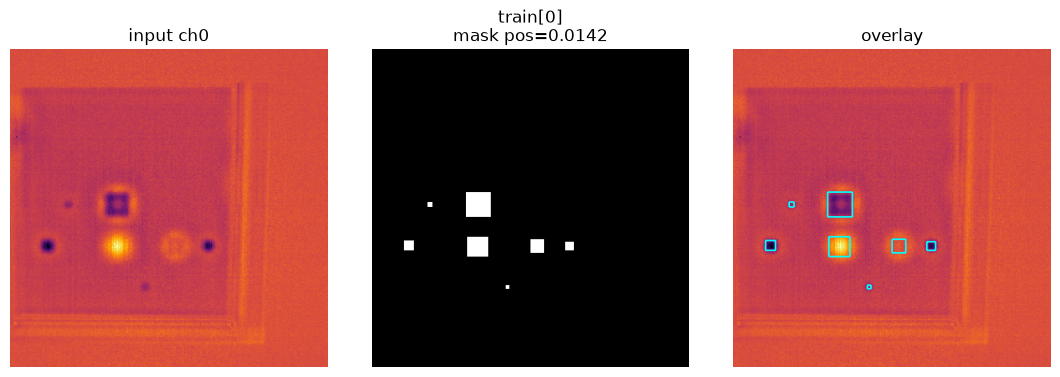

shape img=(6, 256, 256)  mask=(1, 256, 256)  pos=0.0142


In [16]:
SPLIT = "train"   # "train" | "test"
INDEX = 0
CHANNEL = 0


def show_dataset_sample(ds, idx: int, *, ch: int = 0, title: str = "") -> None:
    n = len(ds)
    if idx < 0 or idx >= n:
        raise IndexError(f"INDEX={idx} вне диапазона 0..{n - 1}")
    img, mask = ds[idx]
    img_np = img[ch].numpy() if isinstance(img, torch.Tensor) else np.asarray(img[ch])
    mask_np = mask.squeeze().numpy() if isinstance(mask, torch.Tensor) else np.asarray(mask).squeeze()
    pos = float(mask_np.mean())

    fig, ax = plt.subplots(1, 3, figsize=(11, 3.8))
    fig.suptitle(title or f"{SPLIT}[{idx}] / n={n}", fontsize=12)
    ax[0].imshow(img_np, cmap="inferno"); ax[0].set_title(f"input ch{ch}")
    ax[1].imshow(mask_np, cmap="gray", vmin=0, vmax=1); ax[1].set_title(f"mask pos={pos:.4f}")
    ax[2].imshow(img_np, cmap="inferno"); ax[2].contour(mask_np, levels=[0.5], colors="cyan", linewidths=1.2)
    ax[2].set_title("overlay")
    for a in ax:
        a.axis("off")
    fig.tight_layout()
    plt.show()
    print(f"shape img={tuple(img.shape)}  mask={tuple(mask.shape)}  pos={pos:.4f}")


ds_view = train_ds if SPLIT == "train" else test_ds
show_dataset_sample(ds_view, INDEX, ch=CHANNEL, title=f"{SPLIT}[{INDEX}]")

In [17]:
def plot_history_live(history: list[dict], *, title: str = "") -> None:
    if not history:
        return
    epochs = [float(r["epoch"]) for r in history]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    fig.suptitle(title or f"Attention U-Net ({VARIANT})", fontsize=12)
    for ax, key, ylab in zip(
        axes,
        [("train_loss", "test_loss"), ("train_iou", "test_iou"), ("train_dice", "test_dice")],
        ["loss", "IoU", "Dice"],
    ):
        ax.plot(epochs, [float(r[key[0]]) for r in history], "o-", label="train", ms=3)
        ax.plot(epochs, [float(r[key[1]]) for r in history], "o-", label="test", ms=3)
        ax.set_title(ylab); ax.set_xlabel("epoch"); ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


def _on_epoch_end(tracker, row, epoch, end_epoch, best_iou, best_epoch, opt):
    clear_output(wait=True)
    print(tracker.format_line(row, end_epoch))
    print(f"lr={opt.param_groups[0]['lr']:.2e}  best test IoU {best_iou:.4f} @ {best_epoch}")
    plot_history_live(tracker.history, title=f"AttUNet {VARIANT} — epoch {epoch}/{end_epoch}")

In [ ]:
tracker, model, best_iou, best_epoch = train_one(
    VARIANT,
    yaml_path,
    EPOCHS,
    device,
    test_every=TEST_EVERY,
    batch_size=bs,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    pos_weight=POS_WEIGHT,
    compile_model=COMPILE,
    num_workers=nw,
    resume=RESUME,
    on_epoch_end=_on_epoch_end,
)

print(f"\nbest test IoU {best_iou:.4f} @ epoch {best_epoch}")
print(f"history: {tracker.json_path}")


=== AttUNet tsr | mps | in_ch=6 | bs=8 workers=0 | 50 ep ===
train: 44 videos / 880 samples  test: 12 videos / 12 samples
torch.compile enabled on mps
optimizer=AdamW lr=0.0003 weight_decay=0.0001 sched=cosine loss=BCE+Dice pos_weight=None channels_last=False
starting epochs 1..50 — first batch + torch.compile can take 1–3 min…


train 1:  22%|██▏       | 24/110 [02:07<07:09,  4.99s/it, loss=1.4] 

In [ ]:
# превью предсказания (как eval.py)
model.eval()
img, mask = test_ds[0]
with torch.no_grad():
    logits = model(img.unsqueeze(0).to(device))
    prob = torch.sigmoid(logits).squeeze().cpu().numpy()
pred = (prob > 0.5).astype(np.float32)
gt = mask.squeeze().numpy()

fig, ax = plt.subplots(1, 4, figsize=(14, 3.5))
ax[0].imshow(img[0].numpy(), cmap="inferno"); ax[0].set_title("input ch0")
ax[1].imshow(gt, cmap="gray", vmin=0, vmax=1); ax[1].set_title("GT")
ax[2].imshow(prob, cmap="magma", vmin=0, vmax=1); ax[2].set_title("prob")
ax[3].imshow(pred, cmap="gray", vmin=0, vmax=1); ax[3].set_title("pred (>0.5)")
for a in ax:
    a.axis("off")
fig.tight_layout()
plt.show()